# Coronary Heart disease  prediction using DL

In [ ]:
# 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import style
style.use("ggplot")
%matplotlib inline
import seaborn as sns
from tkinter import *
import tkinter.messagebox as M
import warnings
warnings.filterwarnings('ignore')
import keras
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score   
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D, concatenate, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
###  load  the  dataset 

df=pd.read_csv("H:/mldataset/framingham.csv")
df.head()   #### display  5 rows 
df1=df.drop(columns=["education"])
df1.head()
features_to_drop = ['currentSmoker', 'diaBP']
df2=df1.drop(columns=features_to_drop)   #  df1.drop(features_to_drop,axis=1)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')
df3=pd.DataFrame(imputer.fit_transform(df2))
df3.columns = df2.columns
df3.index = df3.index

a=len(df3[df3['BMI'] > 43])
b=len(df3[df3['heartRate'] > 125])
c=len(df3[df3['glucose'] > 200])
d=len( df3[df3['totChol'] > 450])
e=len(df3[df3['sysBP'] > 220])

#print('Number of training examples to be deleted for outliers removal is ',x)
df3 = df3[~(df3['sysBP'] > 220)]
df3 = df3[~(df3['BMI'] > 43)]
df3 = df3[~(df3['heartRate'] > 125)]
df3 = df3[~(df3['glucose'] > 200)]
df3 = df3[~(df3['totChol'] > 450)]
#print(df3.shape)

# Normalize some features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_to_standardise = ['age','cigsPerDay','totChol','sysBP',\
                       'BMI', 'heartRate', 'glucose']
df3[cols_to_standardise] = scaler.fit_transform(df3[cols_to_standardise])

X=df3.drop(columns=["TenYearCHD"])
Y=df3.TenYearCHD
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=40)
##########################################################################
def cnn():
    global acc_cnn
    ## Build 1D CNN model

    model_cnn = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
                                ])

    # Compile the model
    optimizer = Adam(learning_rate=0.001)
    model_cnn.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC()])

    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Train the model
    model_cnn.fit(X_train, Y_train,
                       epochs=100, 
                       batch_size=32, 
                       validation_split=0.2, 
                       callbacks=[early_stopping],
                       class_weight={0:1, 1:4})  # Handling class imbalance


    # Evaluate on test set
    Y_pred_prob = model_cnn.predict(X_test)
    Y_pred_cnn = (Y_pred_prob > 0.5).astype(int)
    acc_cnn=accuracy_score(Y_test,Y_pred_cnn)
    acc_cnn=round(acc_cnn*100,2)
    M.showinfo(title="1d cnn",message="Accuracy is"+str(acc_cnn))

def ann():
    global acc_ann
    global model_ann
    global scaler
    # define the model
    model_ann=Sequential()
    model_ann.add(Dense(units=10,input_dim=12,activation='relu'))
    model_ann.add(Dense(units=5,activation='relu'))
    model_ann.add(Dense(units=1,activation='sigmoid'))
    #compile the model
    model_ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    # train the model
    model_ann.fit(X_train,Y_train,batch_size=20,epochs=100)
    #test the model
    Y_pred_ann=model_ann.predict(X_test)
    Y_pred_ann=(Y_pred_ann>0.5).astype('int').reshape(-1)
    #find accuracy
    from sklearn.metrics import accuracy_score
    acc_ann=accuracy_score(Y_test,Y_pred_ann)
    acc_ann=round(acc_ann*100,2)
    M.showinfo(title="ANN",message="Accuracy is"+str(acc_ann))
def unet():
    global X_train
    global X_test
    global acc_unet
    #Reshape for 1D U-Net (samples, features, channels)
    X_train = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

    ## Build 1D U-Net inspired model
    def build_unet(input_shape):
        inputs = Input(input_shape)

        # Contracting Path (Encoder)
        c1 = Conv1D(64, 3, activation='relu', padding='same')(inputs)
        c1 = BatchNormalization()(c1)
        p1 = MaxPooling1D(2)(c1)

        c2 = Conv1D(128, 3, activation='relu', padding='same')(p1)
        c2 = BatchNormalization()(c2)
        p2 = MaxPooling1D(2)(c2)

        # Bottleneck
        b1 = Conv1D(256, 3, activation='relu', padding='same')(p2)
        b1 = BatchNormalization()(b1)

        # Expanding Path (Decoder)
        u2 = UpSampling1D(2)(b1)
        u2 = concatenate([u2, c2])
        c3 = Conv1D(128, 3, activation='relu', padding='same')(u2)
        c3 = BatchNormalization()(c3)

        u1 = UpSampling1D(2)(c3)
        u1 = concatenate([u1, c1])
        c4 = Conv1D(64, 3, activation='relu', padding='same')(u1)
        c4 = BatchNormalization()(c4)

        # Final layers for classification
        flat = Flatten()(c4)
        dense1 = Dense(128, activation='relu')(flat)
        dropout = Dropout(0.5)(dense1)
        outputs = Dense(1, activation='sigmoid')(dropout)

        model = Model(inputs=[inputs], outputs=[outputs])
        return model

    # Create model
    model_unet = build_unet((X_train.shape[1], 1))
    model_unet.summary()

    # Compile the model
    optimizer = Adam(learning_rate=0.001)
    model_unet.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy', tf.keras.metrics.AUC()])

    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Train the model
    model_unet.fit(X_train, Y_train, 
                       epochs=100, 
                       batch_size=32, 
                       validation_split=0.2, 
                       callbacks=[early_stopping],
                       class_weight={0:1, 1:4})  # Handling class imbalance

    

    

    # Evaluate on test set
    y_pred_prob = model_unet.predict(X_test)
    Y_pred = (y_pred_prob > 0.5).astype(int)
    acc_unet=accuracy_score(Y_test,Y_pred)
    acc_unet=round(acc_unet*100,2)
    M.showinfo(title="unet",message="Accuracy is"+str(acc_unet))

   
def compare():
    global acc_cnn
    global acc_ann
    global acc_unet
    
    models=['ANN','CNN','UNET']
    accuracy=[acc_ann,acc_cnn,acc_unet]
    plt.bar(models,accuracy,color=["green","red",'blue'],edgecolor="black",linewidth=5,width=0.5)
    plt.xlabel("MODELS",fontsize="20",color="red")
    plt.ylabel("ACCURACY",fontsize=20,color="blue")
    plt.grid(color="black",linestyle="--",linewidth=2)
    plt.show()
    M.showinfo(title='BEST MODEL',message="ANN")

def predict():
    global model_ann
    a=float(v1.get())#male
    b=float(v2.get())#age
    c=float(v3.get())#cigsPerDay
    d=float(v4.get())#BPMeds
    e=float(v5.get())#prevalentStroke
    f=float(v6.get())#prevalentHyp
    g=float(v7.get())#diabetes
    h=float(v8.get())#totChol
    i=float(v9.get())#sysbp
    j=float(v10.get())#BMI
    k=float(v11.get())#Heart rate
    l=float(v12.get())#glucose
    #----------------------------------------------------------------
    ###'age','totChol','sysBP',\
                      ## 'BMI', 'heartRate', 'glucose', 'cigsPerDay']
    #b,c,h,i,j,k,l
    
    new = scaler.transform([[b,c,h,i,j,k,l]])
    b1=new[0][0]
    c1=new[0][1]
    h1=new[0][2]
    i1=new[0][3]
    j1=new[0][4]
    k1=new[0][5]
    l1=new[0][6]
    #print(a,b1,c1,d,e,f,g,h1,i1,j1,l1)
    ##----------------------------------------------------------------
    ######predict by ANN  as it is best
    result=model_ann.predict([[a,b1,c1,d,e,f,g,h1,i1,j1,k1,l1]])
    print(result)
    result1=int(result[0][0]>0.5)
    if result1==1:
        M.showinfo(title="heart Disease prediction",message="You may suffer from heart problem")
    else:
        M.showinfo(title="heart Disease prediction",message="You  dont have heart problem")
   
def reset():
    v1.set("")
    v2.set("")
    v3.set("")
    v4.set("")
    v5.set("")
    v6.set("")
    v7.set("")
    v8.set("")
    v9.set("")
    v10.set("")
    v11.set("")
    v12.set("")    
w=Tk()
w.configure(bg='gray')
w.title(" CORONARY HEART DISEASE PREDICTION")
v1=StringVar()
v2=StringVar()
v3=StringVar()
v4=StringVar()
v5=StringVar()
v6=StringVar()
v7=StringVar()
v8=StringVar()
v9=StringVar()
v10=StringVar()
v11=StringVar()
v12=StringVar()

L0=Label(w,relief="solid",font=('arial',20,'bold'),text=" CORONARY HEART DISEASE PREDICTION USING DEEP LEARNING    ",bg='white',fg='red',)

#B2=Button(w,pady=5,bd=5,bg="violet",command=logreg,text='Logistic Regression',font=('arial',15,'bold'))
#B3=Button(w,pady=5,bd=5,bg="violet",command=naivebayes,text='Naive Bayes',font=('arial',15,'bold'))
#B4=Button(w,pady=5,bd=5,bg="violet",command=decisiontree,text='Decision Tree Classifier',font=('arial',15,'bold'))
#B5=Button(w,pady=5,bd=5,bg="violet",command=svm,text='Support Vector Machine',font=('arial',15,'bold'))
#B6=Button(w,pady=5,bd=5,bg="violet",command=rf,text='Random Forest Classifier',font=('arial',15,'bold'))
B1=Button(w,pady=5,bd=5,bg='violet',command=ann,text="ANN MODEL",font=('arial',15,'bold'))
B2=Button(w,pady=5,bd=5,bg="violet",command=cnn,text='CNN 1D MODEL',font=('arial',15,'bold'))
B3=Button(w,pady=5,bd=5,bg="violet",command=unet,text='UNET MODEL',font=('arial',15,'bold'))
L0.grid(row=1,column=1,columnspan=4)
B1.grid(row=2,column=1)
B2.grid(row=2,column=2)
B3.grid(row=2,column=3)
####################################################
L1=Label(w,text='MALE',font=('arial',15,'bold'))
L2=Label(w,text='AGE',font=('arial',15,'bold'))
L3=Label(w,text='CIGARETTE PER DAY',font=('arial',15,'bold'))
L4=Label(w,text='BP MEDICINE',font=('arial',15,'bold'))
L5=Label(w,text='HEART STROKE IN PAST',font=('arial',15,'bold'))
L6=Label(w,text='HYPERTENSION',font=('arial',15,'bold'))
L7=Label(w,text='DIABETES',font=('arial',15,'bold'))
L8=Label(w,text='CHOLESTEROL',font=('arial',15,'bold'))
L9=Label(w,text='BLOOD PRESSURE',font=('arial',15,'bold'))
L10=Label(w,text='BODY MASS INDEX',font=('arial',15,'bold'))
L11=Label(w,text='HEART RATE',font=('arial',15,'bold'))
L12=Label(w,text='GLUCOSE',font=('arial',15,'bold'))

E1=Entry(w,bd=5,textvariable=v1,bg='cyan',font=('arial',15,'bold'))
E2=Entry(w,bd=5,textvariable=v2,bg='cyan',font=('arial',15,'bold'))
E3=Entry(w,bd=5,textvariable=v3,bg='cyan',font=('arial',15,'bold'))
E4=Entry(w,bd=5,textvariable=v4,bg='cyan',font=('arial',15,'bold'))
E5=Entry(w,bd=5,textvariable=v5,bg='cyan',font=('arial',15,'bold'))
E6=Entry(w,bd=5,textvariable=v6,bg='cyan',font=('arial',15,'bold'))
E7=Entry(w,bd=5,textvariable=v7,bg='cyan',font=('arial',15,'bold'))
E8=Entry(w,bd=5,textvariable=v8,bg='cyan',font=('arial',15,'bold'))
E9=Entry(w,bd=5,textvariable=v9,bg='cyan',font=('arial',15,'bold'))
E10=Entry(w,bd=5,textvariable=v10,bg='cyan',font=('arial',15,'bold'))
E11=Entry(w,bd=5,textvariable=v11,bg='cyan',font=('arial',15,'bold'))
E12=Entry(w,bd=5,textvariable=v12,bg='cyan',font=('arial',15,'bold'))

#################################################
L1.grid(row=4,column=1)
E1.grid(row=4,column=2)
L2.grid(row=4,column=3)
E2.grid(row=4,column=4)
L3.grid(row=5,column=1)
E3.grid(row=5,column=2)
L4.grid(row=5,column=3)
E4.grid(row=5,column=4)
#######################################
L5.grid(row=6,column=1)
E5.grid(row=6,column=2)
L6.grid(row=6,column=3)
E6.grid(row=6,column=4)
L7.grid(row=7,column=1)
E7.grid(row=7,column=2)
L8.grid(row=7,column=3)
E8.grid(row=7,column=4)
###################################################
L9.grid(row=8,column=1)
E9.grid(row=8,column=2)
L10.grid(row=8,column=3)
E10.grid(row=8,column=4)
L11.grid(row=9,column=1)
E11.grid(row=9,column=2)
L12.grid(row=9,column=3)
E12.grid(row=9,column=4)

########################################
Bsub=Button(w,bd=5,relief="solid",bg='white',fg="blue",text="SUBMIT",font=('arial',15,'bold'),command=predict)
Bres=Button(w,bd=5,relief="solid",bg='white',fg='blue',text="CLEAR DATA",font=('arial',15,'bold'),command=reset)

Bcmp=Button(w,bd=5,pady=8,relief="solid",bg='white',\
            fg="blue",command=compare,text='MODEL COMPARASION',font=('arial',20,'bold'))
Bcmp.grid(row=2,column=4)
Bsub.grid(row=10,column=3)
Bres.grid(row=10,column=4)
##############################################
Lend=Label(w,relief="solid",font=('arial',20,'bold'),text=" CORONARY HEART DISEASE PREDICTION USING DEEP LEARNING    ",bg='white',fg='red',)
Lend.grid(row=11,column=1,columnspan=4)
w.mainloop()    

Epoch 1/100
168/168 [==============================] - 1s 2ms/step - loss: 0.6665 - accuracy: 0.8215
Epoch 2/100
168/168 [==============================] - 0s 2ms/step - loss: 0.6176 - accuracy: 0.8514
Epoch 3/100
168/168 [==============================] - 0s 2ms/step - loss: 0.5779 - accuracy: 0.8517
Epoch 4/100
168/168 [==============================] - 0s 2ms/step - loss: 0.5454 - accuracy: 0.8517
Epoch 5/100
168/168 [==============================] - 0s 2ms/step - loss: 0.5187 - accuracy: 0.8517
Epoch 6/100
168/168 [==============================] - 0s 2ms/step - loss: 0.4971 - accuracy: 0.8517
Epoch 7/100
168/168 [==============================] - 0s 2ms/step - loss: 0.4796 - accuracy: 0.8517
Epoch 8/100
168/168 [==============================] - 0s 2ms/step - loss: 0.4656 - accuracy: 0.8517
Epoch 9/100
168/168 [==============================] - 0s 2ms/step - loss: 0.4546 - accuracy: 0.8517
Epoch 10/100
168/168 [==============================] - 0s 2ms/step - loss: 0.4458 - accura

1

# 1  D   CNN

Epoch 1/100
74/74 [==============================] - 2s 11ms/step - loss: 1.5234 - accuracy: 0.5795 - auc_6: 0.4902 - val_loss: 0.9590 - val_accuracy: 0.1809 - val_auc_6: 0.5014
Epoch 2/100
74/74 [==============================] - 1s 7ms/step - loss: 1.3160 - accuracy: 0.5885 - auc_6: 0.4978 - val_loss: 1.1515 - val_accuracy: 0.1587 - val_auc_6: 0.4768
Epoch 3/100
74/74 [==============================] - 1s 7ms/step - loss: 1.1957 - accuracy: 0.5932 - auc_6: 0.5105 - val_loss: 1.0086 - val_accuracy: 0.1536 - val_auc_6: 0.4613
Epoch 4/100
74/74 [==============================] - 1s 8ms/step - loss: 1.0882 - accuracy: 0.6269 - auc_6: 0.5424 - val_loss: 0.8910 - val_accuracy: 0.2594 - val_auc_6: 0.4820
Epoch 5/100
74/74 [==============================] - 1s 7ms/step - loss: 1.0448 - accuracy: 0.6551 - auc_6: 0.5450 - val_loss: 0.6668 - val_accuracy: 0.6263 - val_auc_6: 0.5041
Epoch 6/100
74/74 [==============================] - 1s 8ms/step - loss: 1.0587 - accuracy: 0.6500 - auc_6: 0.5071

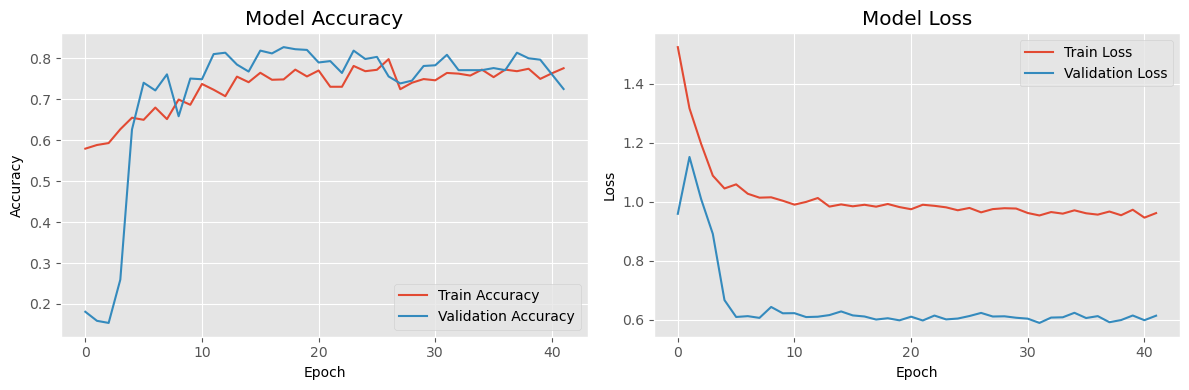

23/23 [==============================] - 0s 2ms/step


NameError: name 'y_pred_prob' is not defined

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

## Load and prepare the dataset

df = pd.read_csv('H:/mldataset/framingham.csv')

# Drop rows with missing values
df = df.dropna()

# Separate features and target
X = df.drop(['TenYearCHD'], axis=1)
Y = df['TenYearCHD']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for 1D CNN (samples, timesteps, features)
# We consider each feature as a time step (even though they're not temporal)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

## Build 1D CNN model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC()])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, Y_train, 
                   epochs=100, 
                   batch_size=32, 
                   validation_split=0.2, 
                   callbacks=[early_stopping],
                   class_weight={0:1, 1:4})  # Handling class imbalance

## Evaluate the model
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate on test set
Y_pred_prob = model.predict(X_test)
Y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred))

print("\nROC AUC Score:", roc_auc_score(Y_test, Y_pred_prob))

# Feature importance analysis (optional)
# This helps understand which features the model finds most important
from tensorflow.keras import backend as K

def get_feature_importance(model, X, feature_names):
    """Calculate feature importance using gradient-based method"""
    input_tensor = model.input
    output_tensor = model.output
    
    # Get gradients of output with respect to input
    gradients = K.gradients(output_tensor, input_tensor)[0]
    
    # Function to get gradients
    get_gradients = K.function([input_tensor], [gradients])
    
    # Calculate gradients for all samples
    grads = get_gradients([X])[0]
    grads = np.mean(np.abs(grads), axis=0)
    
    # Normalize and create feature importance dataframe
    grads = grads / np.sum(grads)
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': grads.flatten()
    }).sort_values('Importance', ascending=False)
    
    return importance_df



#  Unet model

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D, concatenate, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam



# Reshape for 1D U-Net (samples, features, channels)
X_train = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

## Build 1D U-Net inspired model
def build_unet(input_shape):
    inputs = Input(input_shape)
    
    # Contracting Path (Encoder)
    c1 = Conv1D(64, 3, activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling1D(2)(c1)
    
    c2 = Conv1D(128, 3, activation='relu', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling1D(2)(c2)
    
    # Bottleneck
    b1 = Conv1D(256, 3, activation='relu', padding='same')(p2)
    b1 = BatchNormalization()(b1)
    
    # Expanding Path (Decoder)
    u2 = UpSampling1D(2)(b1)
    u2 = concatenate([u2, c2])
    c3 = Conv1D(128, 3, activation='relu', padding='same')(u2)
    c3 = BatchNormalization()(c3)
    
    u1 = UpSampling1D(2)(c3)
    u1 = concatenate([u1, c1])
    c4 = Conv1D(64, 3, activation='relu', padding='same')(u1)
    c4 = BatchNormalization()(c4)
    
    # Final layers for classification
    flat = Flatten()(c4)
    dense1 = Dense(128, activation='relu')(flat)
    dropout = Dropout(0.5)(dense1)
    outputs = Dense(1, activation='sigmoid')(dropout)
    
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Create model
model = build_unet((X_train.shape[1], 1))
model.summary()

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, 
              loss='binary_crossentropy', 
              metrics=['accuracy', tf.keras.metrics.AUC()])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, Y_train, 
                   epochs=100, 
                   batch_size=32, 
                   validation_split=0.2, 
                   callbacks=[early_stopping],
                   class_weight={0:1, 1:4})  # Handling class imbalance

## Evaluate the model
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

# Feature importance analysis
def get_feature_importance_unet(model, X, feature_names, n_samples=100):
    """Calculate feature importance by perturbing each feature"""
    baseline_prob = model.predict(X).mean()
    importance_scores = []
    
    for i in range(X.shape[1]):
        X_perturbed = X.copy()
        X_perturbed[:, i, 0] = np.random.permutation(X_perturbed[:, i, 0])
        perturbed_prob = model.predict(X_perturbed).mean()
        importance_scores.append(baseline_prob - perturbed_prob)
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance_scores
    }).sort_values('Importance', ascending=False)
    
    return importance_df

feature_importance = get_feature_importance_unet(model, X_test, X.columns)
print("\nFeature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'values'